In [1]:
import matplotlib.pyplot as plt
#import mplhep as hep
import json

In [2]:
import matplotlib.colors as mcolors
colors = list(mcolors.TABLEAU_COLORS.keys())

In [3]:
with open('residuals.json') as f:
    residuals = json.load(f)

In [4]:
vbl_names = {'x':r'Predicted - true $x$ [um]', 'y':r'Predicted - true $y$ [um]', 'A':r'Predicted - true $\alpha$ [deg.]', 'B':r'Predicted - true $\beta$ [deg.]'}

In [5]:
def draw_one_vbl(vbl, x, d, ax_ii):
    
    x_array = [-1*x]
    y_array = [d['mean_'+vbl]]
    yerr_array = [[d['down68_'+vbl]],[d['up68_'+vbl]]]
    yerr2_array = [[d['mean_downsigma'+vbl]],[d['mean_upsigma'+vbl]]]
    
    line1 = ax_ii.errorbar(x = y_array, y = x_array, xerr=yerr_array, color = colors[x], linestyle='')
    line2 = ax_ii.errorbar(x = y_array, y = x_array, xerr=yerr2_array, elinewidth=10, alpha=0.2, color = colors[x], linestyle='')
    dot1 = ax_ii.scatter(y_array, x_array, marker='o', color = colors[x])

    ax_ii.set_xlabel(vbl_names[vbl])
    ax_ii.set_yticks([])

    return [line1,line2], [dot1]#,dot3,dot4]

def draw_one_vbl_slim(vbl, x, d, ax_ii):
    
    x_array = [-1*x]
    y_array = [d['mean_'+vbl]]
    yerr_array = [[d['down68_'+vbl]],[d['up68_'+vbl]]]
    
    line1 = ax_ii.errorbar(x = y_array, y = x_array, xerr=yerr_array, color = colors[x], linestyle='')
    #line2 = ax_ii.errorbar(x = y_array, y = x_array, xerr=yerr2_array, elinewidth=10, alpha=0.2, color = colors[x], linestyle='')
    dot1 = ax_ii.scatter(y_array, x_array, marker='o', color = colors[x])

    ax_ii.set_xlabel(vbl_names[vbl])
    ax_ii.set_yticks([])

    return [line1], [dot1]#,dot3,dot4]
    
def draw_one_model(x, d, ax, slim = False):

    if slim:     
        line, dots = draw_one_vbl_slim('x', x, d, ax[1][0])
        line, dots = draw_one_vbl_slim('y', x, d, ax[1][1])
        line, dots = draw_one_vbl_slim('B', x, d, ax[1][3])
        
    else:
        line, dots = draw_one_vbl('x', x, d, ax[1][0])
        line, dots = draw_one_vbl('y', x, d, ax[1][1])
        line, dots = draw_one_vbl('A', x, d, ax[1][2])
        line, dots = draw_one_vbl('B', x, d, ax[1][3])

    return line, dots


In [28]:
# CHANGE: Make draw_* functions robust to your nested schema and A/B→alpha/beta names.
# REASON: The data uses keys like "x", "alpha", "beta" with lists [mean, v2, v3],
#         while the plotting expected flat keys (mean_x, down68_x, ...) and "A"/"B".

def _resolve_vbl_name(vbl):
    # Map A/B to alpha/beta; pass through others (x,y,alpha,beta).
    if vbl == 'A':
        return 'alpha'
    if vbl == 'B':
        return 'beta'
    return vbl

def _extract_stats(d, vbl_resolved):
    """
    Return: mean, down68, up68, has_pred_band, pred_down, pred_up
    Supports two schemas:
      1) Flat keys: mean_x, down68_x, up68_x, mean_downsigmax, mean_upsigmax
      2) Nested triplet: d['x'] = [mean, down68, up68] (asymmetric allowed)
    If 'predicted-σ' band is not available, has_pred_band=False and pred_* ignored.
    """
    # Try flat schema first
    k_mean = f"mean_{vbl_resolved}"
    k_dn   = f"down68_{vbl_resolved}"
    k_up   = f"up68_{vbl_resolved}"
    k_pdn  = f"mean_downsigma{vbl_resolved}"
    k_pup  = f"mean_upsigma{vbl_resolved}"

    if k_mean in d and k_dn in d and k_up in d:
        mean = d[k_mean]
        dn   = d[k_dn]
        up   = d[k_up]
        if k_pdn in d and k_pup in d:
            return mean, dn, up, True, d[k_pdn], d[k_pup]
        else:
            return mean, dn, up, False, None, None

    # Fallback: nested list/tuple
    if vbl_resolved in d and isinstance(d[vbl_resolved], (list, tuple)):
        arr = d[vbl_resolved]
        mean = arr[0] if len(arr) > 0 else 0.0
        # Heuristic: interpret arr[1], arr[2] as asymmetric ±68% half-widths.
        # If only one additional number, treat as symmetric.
        if len(arr) >= 3:
            dn, up = arr[1], arr[2]
        elif len(arr) == 2:
            dn = up = arr[1]
        else:
            dn = up = 0.0
        # No predicted-σ band available in this schema
        return mean, dn, up, False, None, None

    # Nothing available
    return None, None, None, False, None, None

# CHANGE: Add marker-per-config mapping.
# REASON: Match legend shapes to configuration semantics (20t/2t/input-dig/wb-quant).
CONFIG_MARKERS = {
    "no-quant-20": "o",   # • Full precision, 20 frames
    "no-quant":    "s",   # ■ Full precision, 2 frames
    "input-dig":   "v",   # ▼ Digitized inputs
    "wb-quant":    "^",   # ▲ Quantized network params
}
def _marker_for_config(cfg):
    return CONFIG_MARKERS.get(cfg, "o")  # default circle

# CHANGE: Ensure stable per-model colors.
# REASON: Same model = same color across all panels.
colors = {0: 'C0', 1: 'C1', 2: 'C2', 3: 'C3'}

# (keep _resolve_vbl_name and _extract_stats as you have them)

# CHANGE: Accept 'marker' and use it in the scatter/errorbar calls.
# REASON: Shape encodes config, color encodes model.
def draw_one_vbl(vbl, x, d, ax_ii, marker="o"):
    vbl_resolved = _resolve_vbl_name(vbl)
    x_array = [-1*x]
    mean, dn, up, has_pred, pdn, pup = _extract_stats(d, vbl_resolved)
    if mean is None:
        return [], []
    y_array = [mean]
    c = colors.get(x, 'C0')

    line1 = ax_ii.errorbar(x=y_array, y=x_array, xerr=[[dn],[up]], linestyle='', color=c)
    lines = [line1]
    if has_pred:
        line2 = ax_ii.errorbar(x=y_array, y=x_array, xerr=[[pdn],[pup]], elinewidth=10, alpha=0.2, linestyle='', color=c)
        lines.append(line2)
    dot1  = ax_ii.scatter(y_array, x_array, marker=marker, color=c)
    ax_ii.set_xlabel(vbl)  # or vbl_names.get(vbl, vbl)
    ax_ii.set_yticks([])
    return lines, [dot1]

def draw_one_vbl_slim(vbl, x, d, ax_ii, marker="o"):
    vbl_resolved = _resolve_vbl_name(vbl)
    x_array = [-1*x]
    mean, dn, up, *_ = _extract_stats(d, vbl_resolved)
    if mean is None:
        return [], []
    y_array = [mean]
    c = colors.get(x, 'C0')

    line1 = ax_ii.errorbar(x=y_array, y=x_array, xerr=[[dn],[up]], linestyle='', color=c)
    dot1  = ax_ii.scatter(y_array, x_array, marker=marker, color=c)
    ax_ii.set_xlabel(vbl)
    ax_ii.set_yticks([])
    return [line1], [dot1]

# CHANGE: Pass config marker through draw_one_model.
# REASON: Model color + config marker jointly encode identity.
def draw_one_model(x, d, ax, slim=False, marker="o"):
    if slim:
        l1, d1 = draw_one_vbl_slim('x', x, d, ax[1][0], marker=marker)
        l2, d2 = draw_one_vbl_slim('y', x, d, ax[1][1], marker=marker)
        l4, d4 = draw_one_vbl_slim('B', x, d, ax[1][3], marker=marker)   # beta
        lines = l1 + l2 + l4
        dots  = d1 + d2 + d4
    else:
        l1, d1 = draw_one_vbl('x', x, d, ax[1][0], marker=marker)
        l2, d2 = draw_one_vbl('y', x, d, ax[1][1], marker=marker)
        l3, d3 = draw_one_vbl('A', x, d, ax[1][2], marker=marker)        # alpha
        l4, d4 = draw_one_vbl('B', x, d, ax[1][3], marker=marker)        # beta
        lines = l1 + l2 + l3 + l4
        dots  = d1 + d2 + d3 + d4
    return lines, dots


/tmp/ipykernel_1169649/2452342398.py:50: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


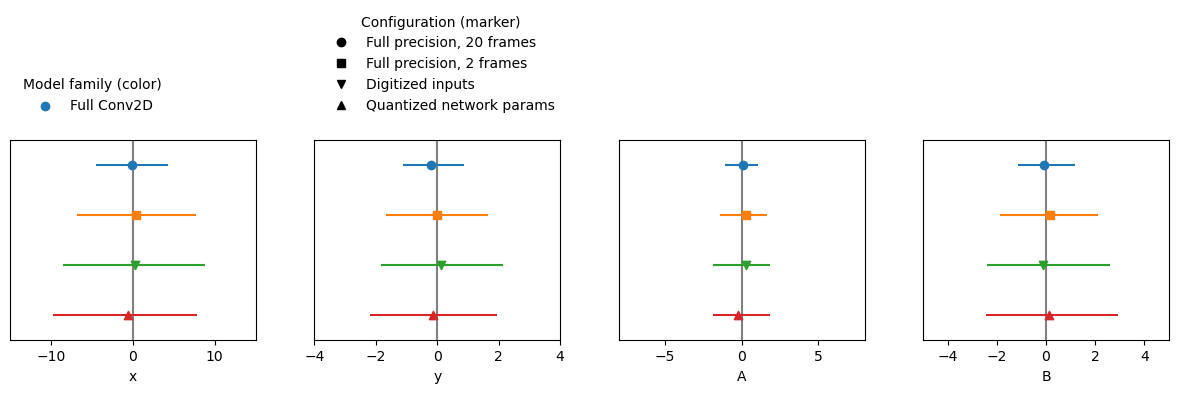

In [29]:
# --- Example wiring with both model and config encoded ---
# CHANGE: Include config key per entry and build both legends: model (color) and config (marker).
# REASON: Two-factor encoding: color → model family; marker → configuration.
model_entries = [
    # (model_dict,              model_label,             is_slim,           config_key)
    (residuals["full_2dconv"]["no-quant-20"], "Full Conv2D",               False, "no-quant-20"),
    (residuals["full_2dconv"]["no-quant"],    "Full Conv2D",               False, "no-quant"),
    (residuals["full_2dconv"]["input-dig"],   "Full Conv2D",               False, "input-dig"),
    (residuals["full_2dconv"]["wb-quant"],    "Full Conv2D",               False, "wb-quant"),
    # add other families similarly; colors will advance by index i
]

fig, ax = plt.subplots(2,4,figsize=(12,4),sharey=True,constrained_layout=True,
                       gridspec_kw={'height_ratios': [1, 3]})
for j in range(4):
    ax[0,j].axis('off')
format_plot(ax, 4)  # your existing helper

# Model legend (colors)
model_handles, model_labels = [], []
# Config legend (markers) using proxy artists
import matplotlib.lines as mlines
cfg_handles = {
    "no-quant-20": mlines.Line2D([], [], linestyle='', marker='o', color='black'),
    "no-quant":    mlines.Line2D([], [], linestyle='', marker='s', color='black'),
    "input-dig":   mlines.Line2D([], [], linestyle='', marker='v', color='black'),
    "wb-quant":    mlines.Line2D([], [], linestyle='', marker='^', color='black'),
}
cfg_labels = {
    "no-quant-20": "Full precision, 20 frames",
    "no-quant":    "Full precision, 2 frames",
    "input-dig":   "Digitized inputs",
    "wb-quant":    "Quantized network params",
}

for i, (m, lab, is_slim, cfg) in enumerate(model_entries):
    marker = _marker_for_config(cfg)
    lines, dots = draw_one_model(i, m, ax, slim=is_slim, marker=marker)
    # one handle per *model color* in legend (first dot returned)
    if dots and lab not in model_labels:
        model_handles.append(dots[0])
        model_labels.append(lab)

# Place legends: left = model colors; right = config markers
ax[0,0].legend(model_handles, model_labels, frameon=False, loc='lower left', title="Model family (color)")
ax[0,1].legend([cfg_handles[k] for k in CONFIG_MARKERS],
               [cfg_labels[k]  for k in CONFIG_MARKERS],
               frameon=False, loc='lower left', title="Configuration (marker)")

plt.tight_layout()
plt.show()


In [23]:
def format_plot(ax, n_models=4, slim=False):
    ax[1][0].plot([0,0],[1,-1*n_models],color='gray', zorder=0)
    ax[1][1].plot([0,0],[1,-1*n_models],color='gray', zorder=0)
    ax[1][2].plot([0,0],[1,-1*n_models],color='gray', zorder=0)
    ax[1][3].plot([0,0],[1,-1*n_models],color='gray', zorder=0)

    # x limits
    ax[1][0].set_xlim(-15,15) # x
    ax[1][1].set_xlim(-4,4) # y
    ax[1][2].set_xlim(-8,8) # alpha
    ax[1][3].set_xlim(-5,5) # beta
    
    ax[1][0].set_ylim(-1*n_models+0.5,0.5)
    ax[1][1].set_ylim(-1*n_models+0.5,0.5)
    ax[1][2].set_ylim(-1*n_models+0.5,0.5) 
    ax[1][3].set_ylim(-1*n_models+0.5,0.5)

/tmp/ipykernel_1169649/2010181548.py:28: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


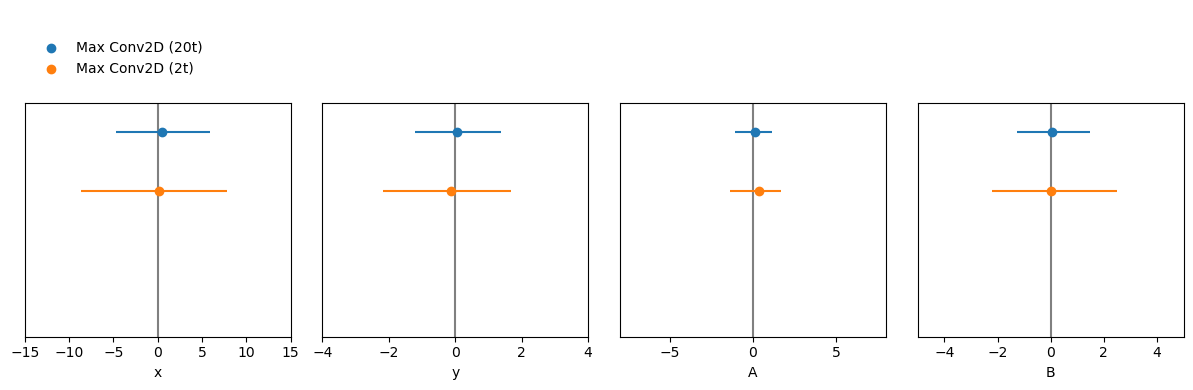

In [27]:



model_entries = [
    (residuals["max_2dconv"]["no-quant-20"],  "Max Conv2D (20t)",  False),
    (residuals["max_2dconv"]["no-quant"],  "Max Conv2D (2t)",  False),
    # (residuals["full_2dconv"]["no-quant-20"], "Full Conv2D (20t)", False),
    # Uncomment/add when you actually plot them:
    # (residuals["full_2dconv"]["no-quant"],    "Full Conv2D (2t)",  False),
    # (residuals["slim_2dconv"]["no-quant"],    "Slim Conv2D (2t)",  True),
]

fig, ax = plt.subplots(2,4,figsize=(12,4),sharey=True,constrained_layout=True,
                       gridspec_kw={'height_ratios': [1, 3]})

for j in range(4):
    ax[0,j].axis('off')

format_plot(ax, 4)  # assuming this is defined elsewhere

legend_handles = []
legend_labels  = []

for i, (m, lab, is_slim) in enumerate(model_entries):
    lines, dots = draw_one_model(i, m, ax, slim=is_slim)
    if dots:  # keep exactly one handle per model
        legend_handles.append(dots[0])
        legend_labels.append(lab)

ax[0,0].legend(legend_handles, legend_labels, frameon=False, loc='lower left')
plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(2,4,figsize=(12,4),sharey=True,constrained_layout=True, gridspec_kw={'height_ratios': [1, 3]})

ax[0,0].axis('off')
ax[0,1].axis('off')
ax[0,2].axis('off')
ax[0,3].axis('off')

dots = []

models = [residuals["max_2dconv"]["1-noquant_20t"],
          residuals["full_2dconv"]["1-noquant_20t"],
          residuals["full_2dconv"]["2-noquant_2t"],
          residuals["full_2dconv"]["3-input_dig_2t"],
          residuals["full_2dconv"]["4-quantized"],
]
format_plot(ax, 5)

for i,m in enumerate(models):
    
    l, d = draw_one_model(i, m, ax)
    dots += d
    
#ax[0][0].legend(lines,[names[l] for l in labels],frameon=False,loc='center left')
ax[0][0].legend(dots,['Max Conv2D (20t)','Full Conv2D (20t)','Full Conv2D (2t)','Full Conv2D (digitized)','Full Conv2D (quantized)'],frameon=False,loc='lower left')

plt.tight_layout()

plt.savefig("plots/cpad-5.pdf")
plt.savefig("plots/cpad-5.png")

plt.show()

/tmp/ipykernel_3653743/3588529979.py:26: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


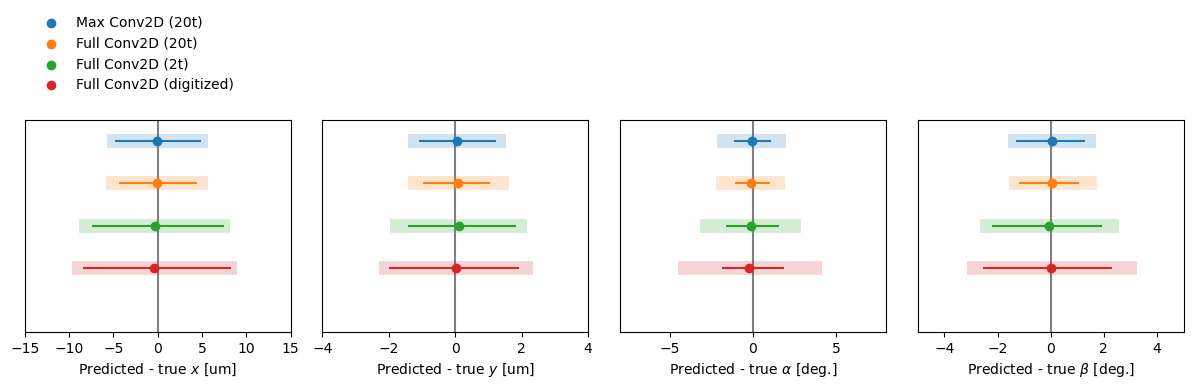

In [9]:
fig, ax = plt.subplots(2,4,figsize=(12,4),sharey=True,constrained_layout=True, gridspec_kw={'height_ratios': [1, 3]})

ax[0,0].axis('off')
ax[0,1].axis('off')
ax[0,2].axis('off')
ax[0,3].axis('off')

dots = []

models = [residuals["max_2dconv"]["1-noquant_20t"],
          residuals["full_2dconv"]["1-noquant_20t"],
          residuals["full_2dconv"]["2-noquant_2t"],
          residuals["full_2dconv"]["3-input_dig_2t"],
          #residuals["full_2dconv"]["4-quantized"],
         ]
format_plot(ax, 5)

for i,m in enumerate(models):
    
    l, d = draw_one_model(i, m, ax)
    dots += d
    
#ax[0][0].legend(lines,[names[l] for l in labels],frameon=False,loc='center left')
ax[0][0].legend(dots,['Max Conv2D (20t)','Full Conv2D (20t)','Full Conv2D (2t)','Full Conv2D (digitized)',],frameon=False,loc='lower left')

plt.tight_layout()

plt.savefig("plots/cpad-4.pdf")
plt.savefig("plots/cpad-4.png")

plt.show()

/tmp/ipykernel_3653743/1907094654.py:25: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


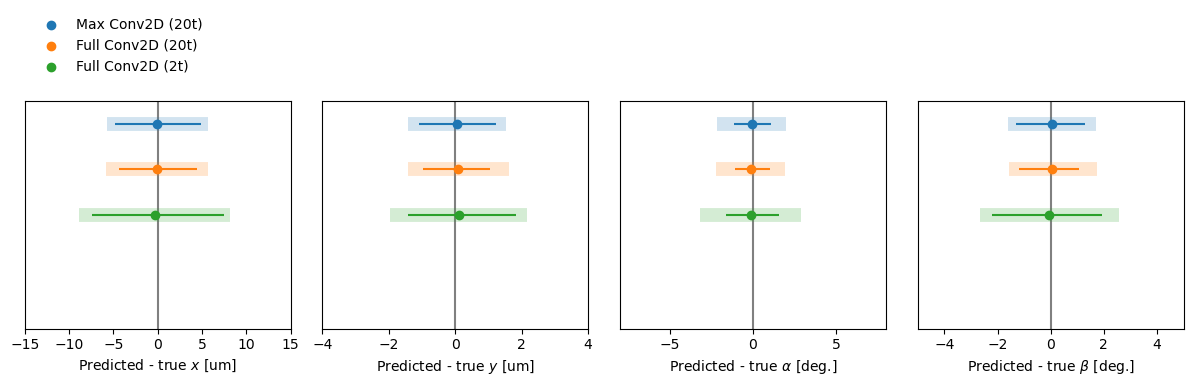

In [10]:
fig, ax = plt.subplots(2,4,figsize=(12,4),sharey=True,constrained_layout=True, gridspec_kw={'height_ratios': [1, 3]})

ax[0,0].axis('off')
ax[0,1].axis('off')
ax[0,2].axis('off')
ax[0,3].axis('off')

dots = []

models = [residuals["max_2dconv"]["1-noquant_20t"],
          residuals["full_2dconv"]["1-noquant_20t"],
          residuals["full_2dconv"]["2-noquant_2t"],
          #residuals["full_2dconv"]["3-input_dig_2t"]
         ]
format_plot(ax, 5)

for i,m in enumerate(models):
    
    l, d = draw_one_model(i, m, ax)
    dots += d
    
#ax[0][0].legend(lines,[names[l] for l in labels],frameon=False,loc='center left')
ax[0][0].legend(dots,
                [
                     'Max Conv2D (20t)',
                     'Full Conv2D (20t)',
                     'Full Conv2D (2t)',
                ],
                frameon=False,loc='lower left')

plt.tight_layout()

plt.savefig("plots/cpad-3.pdf")
plt.savefig("plots/cpad-3.png")

plt.show()

/tmp/ipykernel_3653743/3787437348.py:25: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


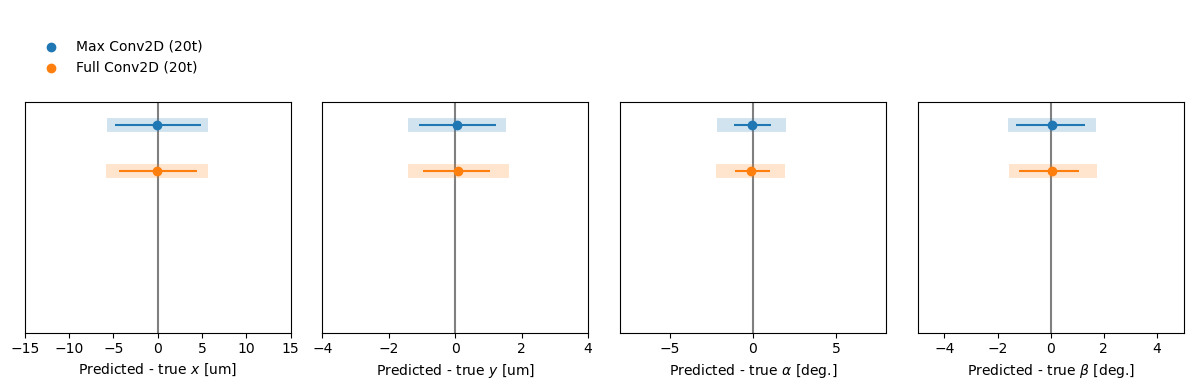

In [11]:
fig, ax = plt.subplots(2,4,figsize=(12,4),sharey=True,constrained_layout=True, gridspec_kw={'height_ratios': [1, 3]})

ax[0,0].axis('off')
ax[0,1].axis('off')
ax[0,2].axis('off')
ax[0,3].axis('off')

dots = []

models = [residuals["max_2dconv"]["1-noquant_20t"],
          residuals["full_2dconv"]["1-noquant_20t"],
          #residuals["full_2dconv"]["2-noquant_2t"],
          #residuals["full_2dconv"]["3-input_dig_2t"]
         ]
format_plot(ax, 5)

for i,m in enumerate(models):
    
    l, d = draw_one_model(i, m, ax)
    dots += d
    
#ax[0][0].legend(lines,[names[l] for l in labels],frameon=False,loc='center left')
ax[0][0].legend(dots,['Max Conv2D (20t)','Full Conv2D (20t)'],frameon=False,loc='lower left')

plt.tight_layout()

plt.savefig("plots/cpad-2.pdf")
plt.savefig("plots/cpad-2.png")

plt.show()

/tmp/ipykernel_3653743/1815658957.py:25: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


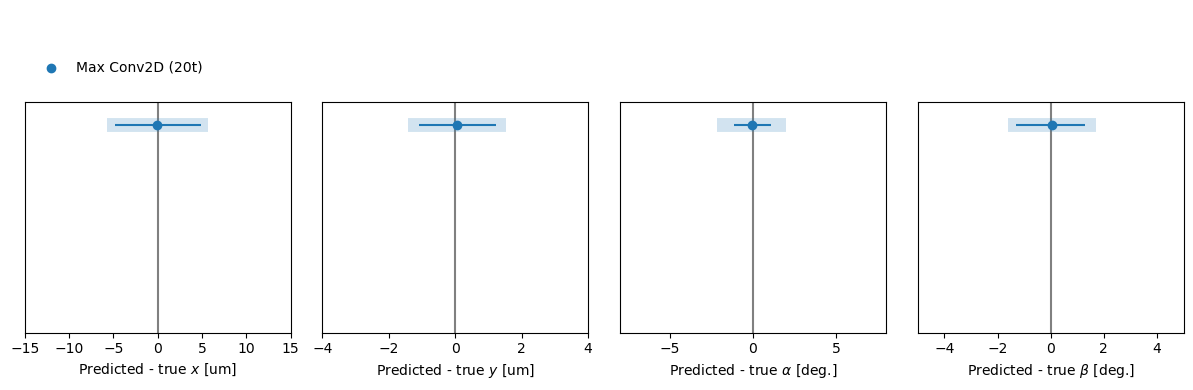

In [12]:
fig, ax = plt.subplots(2,4,figsize=(12,4),sharey=True,constrained_layout=True, gridspec_kw={'height_ratios': [1, 3]})

ax[0,0].axis('off')
ax[0,1].axis('off')
ax[0,2].axis('off')
ax[0,3].axis('off')

dots = []

models = [residuals["max_2dconv"]["1-noquant_20t"],
          #residuals["full_2dconv"]["1-noquant_20t"],
          #residuals["full_2dconv"]["2-noquant_2t"],
          #residuals["full_2dconv"]["3-input_dig_2t"]
         ]
format_plot(ax, 5)

for i,m in enumerate(models):
    
    l, d = draw_one_model(i, m, ax)
    dots += d
    
#ax[0][0].legend(lines,[names[l] for l in labels],frameon=False,loc='center left')
ax[0][0].legend(dots,['Max Conv2D (20t)'],frameon=False,loc='lower left')

plt.tight_layout()

plt.savefig("plots/cpad-1.pdf")
plt.savefig("plots/cpad-1.png")

plt.show()